Initialize

In [1]:
import torch
import random

from environment import Wrapper
from memory_replay import MemoryReplay
from networks import Actor, Critic
from tool_function import Tool

device = Tool.get_gpu()
print(f"Using device: {device}")
env = Wrapper()
memory = MemoryReplay(20000, device)

actor = Actor(3, 128).to(device)
actor_delay = Actor(3, 128).to(device)
actor_delay.load_state_dict(actor.state_dict())
Tool.requires_grad(actor_delay, False)

critic = Critic(4, 128).to(device)
critic_target = Critic(4, 128).to(device)
critic_target.load_state_dict(critic.state_dict())
Tool.requires_grad(critic_target, False)

actorLR = 5e-4
criticLR = 5e-3
optimizer_actor = torch.optim.Adam(actor.parameters(), lr=actorLR)
optimizer_critic = torch.optim.Adam(critic.parameters(), lr=criticLR)

Using device: cuda


Main Functions

In [2]:
def play():
    data = []
    reward_sum = 0

    state = env.reset()
    over = False
    while not over:
        state_tensor = torch.FloatTensor(state).reshape(1, 3).to(device)
        action = actor(state_tensor).item()
        # add noise
        action += random.normalvariate(mu=0, sigma=0.2)

        next_state, reward, over = env.step(action)

        data.append((state, action, reward, next_state, over))
        reward_sum += reward

        state = next_state

    return data, reward_sum


def train_actor(state):
    Tool.requires_grad(actor, True)
    Tool.requires_grad(critic, False)

    action = actor(state)

    input = torch.cat([state, action], dim=1)
    loss = -critic_target(input).mean()

    loss.backward()
    optimizer_actor.step()
    optimizer_actor.zero_grad()

    return loss.item()


def train_critic(state, action, reward, next_state, over):
    Tool.requires_grad(actor, False)
    Tool.requires_grad(critic, True)

    input = torch.cat([state, action], dim=1)
    value = critic(input)

    with torch.no_grad():
        next_action = actor_delay(next_state)
        input = torch.cat([next_state, next_action], dim=1)
        target = critic_target(input)
    target = target * 0.99 * (1 - over) + reward

    loss = torch.nn.functional.mse_loss(value, target)

    loss.backward()
    optimizer_critic.step()
    optimizer_critic.zero_grad()

    return loss.item(), value.mean().item()

Train

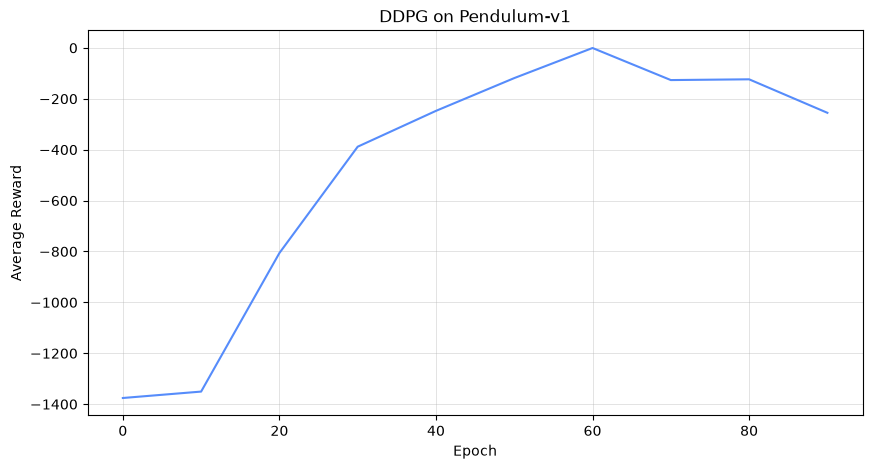

In [3]:
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# make model training mode
actor.train()
critic.train()

epochs_list = []
rewards_list = []

fig, ax = plt.subplots(figsize=(10, 5))

epochs = 100

# train loop
for epoch in range(epochs):
    epoch_rewards = []
    collected = 0
    while collected < 200:
        trajectory, reward_sum = play()
        memory.push(trajectory)
        collected += len(trajectory)
        epoch_rewards.append(reward_sum)

    for i in range(200):
        state, action, reward, next_state, over = memory.sample(128)

        train_actor(state)
        _, value = train_critic(state, action, reward, next_state, over)

        Tool.soft_update(actor, actor_delay)
        Tool.soft_update(critic, critic_target)

    if epoch % 10 == 0:
        avg_train_reward = sum(epoch_rewards) / len(epoch_rewards)
        epochs_list.append(epoch)
        rewards_list.append(avg_train_reward)

        ax.clear()
        ax.plot(epochs_list, rewards_list)
        ax.set_title('DDPG on Pendulum-v1')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Average Reward')
        ax.grid(True)

        clear_output(wait=True)
        display(fig)

plt.close(fig)
env.close()

Result

In [4]:
if 'env' in locals():
    del env
torch.cuda.empty_cache()

env = Wrapper(render_mode='rgb_array')
actor.eval()
critic.eval()

frames = []
state = env.reset()
over = False

while not over:
    state_tensor = torch.FloatTensor(state).reshape(1, 3).to(device)
    action = actor(state_tensor).item()

    next_state, reward, over = env.step(action)
    state = next_state

    # store frame
    frames.append(env.render())
env.close()

# rendor the frames as a video
from matplotlib import animation

from IPython.display import HTML

fig, ax = plt.subplots(figsize=(6, 4))
ax.axis('off')
im = ax.imshow(frames[0])


def update_frame(i):
    im.set_data(frames[i])
    return [im]


ani = animation.FuncAnimation(fig, update_frame, frames=len(frames),
                              interval=33, blit=True, cache_frame_data=True)

video = HTML(ani.to_jshtml())
plt.close(fig)
display(video)